<a href="https://colab.research.google.com/github/mbmanoj904-hue/Generative-ai/blob/main/LSTM_statement_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow Version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

📥 Loading IMDB movie review dataset...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples : 25000

🔄 Padding sequences...
Training shape: (25000, 200)
Testing shape : (25000, 200)

🧠 Building LSTM model...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



🧠 LSTM MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🚀 Training LSTM...

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5228 - loss: 0.6916 - val_accuracy: 0.5584 - val_loss: 0.6787
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5770 - loss: 0.6586 - val_accuracy: 0.5454 - val_loss: 0.6776
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6296 - loss: 0.6015 - val_accuracy: 0.5684 - val_loss: 0.6681
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7111 - loss: 0.5174 - val_accuracy: 0.7600 - val_loss: 0.5342
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7841 - loss: 0.4716 - val_accuracy: 0.7354 - val_loss: 0.5680

📊 FINAL MODEL PERFORMANCE
Test Accuracy : 75.28%
Test Loss     : 0.5474


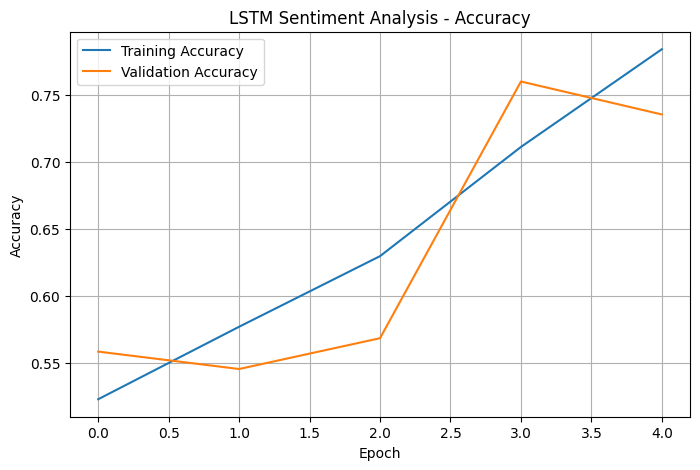

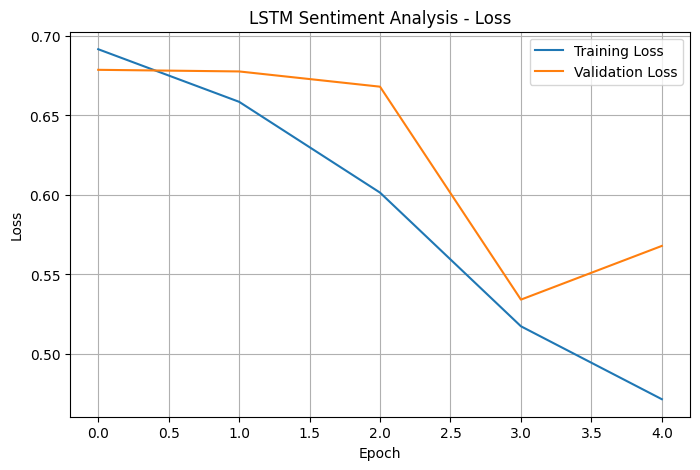


🔍 Generating predictions...


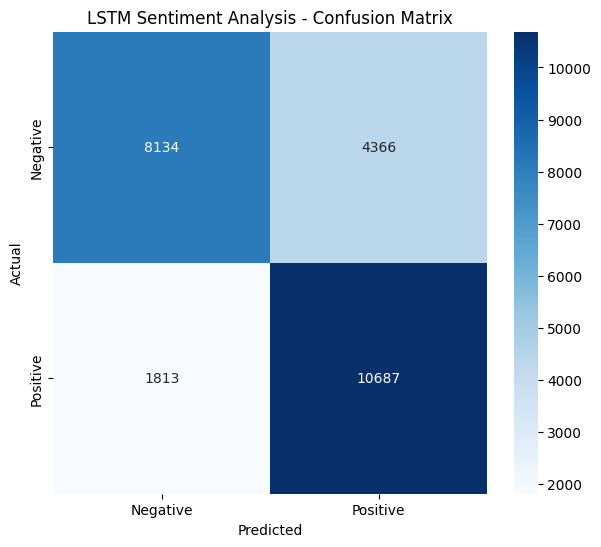


📋 CLASSIFICATION REPORT

              precision    recall  f1-score   support

    Negative       0.82      0.65      0.72     12500
    Positive       0.71      0.85      0.78     12500

    accuracy                           0.75     25000
   macro avg       0.76      0.75      0.75     25000
weighted avg       0.76      0.75      0.75     25000


✅ Model saved as:
/content/sentiment_lstm.keras
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📝 SENTIMENT ANALYSIS
Text: This movie was absolutely amazing. I loved every minute of it.
Sentiment: POSITIVE 😊
Confidence: 75.17%

📝 SENTIMENT ANALYSIS
Text: This movie was terrible and extremely boring.
Sentiment: NEGATIVE 😞
Confidence: 54.29%

✍️ Enter your own movie review.
Enter review: 8.5

📝 SENTIMENT ANALYSIS
Text: 8.5
Sentiment: POSITIVE 😊
Confidence: 75.16%

🎉 LSTM SENTIMENT ANALYSIS PROJECT COMPLETED!


In [1]:
# ============================================================
# 📰 SENTIMENT ANALYSIS USING LSTM
# Google Colab - COMPLETE SINGLE CELL PROJECT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns

# ============================================================
# 1. CHECK TENSORFLOW / GPU
# ============================================================

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# ============================================================
# 2. LOAD IMDB DATASET
# ============================================================

print("\n📥 Loading IMDB movie review dataset...")

VOCAB_SIZE = 10000
MAX_LENGTH = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Training samples:", len(x_train))
print("Testing samples :", len(x_test))

# ============================================================
# 3. PAD SEQUENCES
# ============================================================

print("\n🔄 Padding sequences...")

x_train = pad_sequences(
    x_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

x_test = pad_sequences(
    x_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training shape:", x_train.shape)
print("Testing shape :", x_test.shape)

# ============================================================
# 4. BUILD LSTM MODEL
# ============================================================

print("\n🧠 Building LSTM model...")

model = Sequential([

    # Convert word IDs into dense vectors
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LENGTH
    ),

    # LSTM layer
    LSTM(
        128,
        return_sequences=False
    ),

    # Prevent overfitting
    Dropout(0.5),

    # Fully connected layer
    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    # Binary classification
    Dense(
        1,
        activation="sigmoid"
    )
])

# ============================================================
# 5. COMPILE MODEL
# ============================================================

model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

print("\n==========================================")
print("🧠 LSTM MODEL ARCHITECTURE")
print("==========================================")

model.summary()

# ============================================================
# 6. TRAIN MODEL
# ============================================================

print("\n🚀 Training LSTM...\n")

early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=2,

    restore_best_weights=True
)

history = model.fit(

    x_train,

    y_train,

    validation_split=0.2,

    epochs=5,

    batch_size=64,

    callbacks=[
        early_stopping
    ]
)

# ============================================================
# 7. EVALUATE MODEL
# ============================================================

loss, accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\n==========================================")
print("📊 FINAL MODEL PERFORMANCE")
print("==========================================")

print(
    f"Test Accuracy : {accuracy * 100:.2f}%"
)

print(
    f"Test Loss     : {loss:.4f}"
)

# ============================================================
# 8. ACCURACY GRAPH
# ============================================================

plt.figure(
    figsize=(8,5)
)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "LSTM Sentiment Analysis - Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# 9. LOSS GRAPH
# ============================================================

plt.figure(
    figsize=(8,5)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "LSTM Sentiment Analysis - Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.grid()

plt.show()

# ============================================================
# 10. PREDICTIONS
# ============================================================

print("\n🔍 Generating predictions...")

probabilities = model.predict(
    x_test,
    verbose=0
).flatten()

y_pred = (
    probabilities >= 0.5
).astype(int)

# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
    figsize=(7,6)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[
        "Negative",
        "Positive"
    ],

    yticklabels=[
        "Negative",
        "Positive"
    ]
)

plt.title(
    "LSTM Sentiment Analysis - Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print("\n📋 CLASSIFICATION REPORT\n")

print(
    classification_report(

        y_test,

        y_pred,

        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

# ============================================================
# 13. SAVE MODEL
# ============================================================

model.save(
    "/content/sentiment_lstm.keras"
)

print(
    "\n✅ Model saved as:"
)

print(
    "/content/sentiment_lstm.keras"
)

# ============================================================
# 14. CREATE WORD INDEX
# ============================================================

word_index = imdb.get_word_index()

# Reverse dictionary
reverse_word_index = {
    value + 3: key
    for key, value in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"

# ============================================================
# 15. FUNCTION FOR USER TEXT
# ============================================================

def predict_sentiment(text):

    # Convert text to lowercase
    words = text.lower().split()

    sequence = []

    for word in words:

        index = word_index.get(
            word,
            2
        )

        # Keep within vocabulary
        if index + 3 < VOCAB_SIZE:
            sequence.append(
                index + 3
            )
        else:
            sequence.append(2)

    # Pad
    sequence = pad_sequences(
        [sequence],
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    # Predict
    probability = model.predict(
        sequence,
        verbose=0
    )[0][0]

    if probability >= 0.5:

        sentiment = "POSITIVE 😊"

        confidence = probability * 100

    else:

        sentiment = "NEGATIVE 😞"

        confidence = (1 - probability) * 100

    print("\n==========================================")
    print("📝 SENTIMENT ANALYSIS")
    print("==========================================")

    print(
        "Text:",
        text
    )

    print(
        "Sentiment:",
        sentiment
    )

    print(
        f"Confidence: {confidence:.2f}%"
    )

    print("==========================================")

# ============================================================
# 16. TEST EXAMPLES
# ============================================================

predict_sentiment(
    "This movie was absolutely amazing. I loved every minute of it."
)

predict_sentiment(
    "This movie was terrible and extremely boring."
)

# ============================================================
# 17. ENTER YOUR OWN REVIEW
# ============================================================

print("\n✍️ Enter your own movie review.")

user_text = input(
    "Enter review: "
)

if user_text.strip():

    predict_sentiment(
        user_text
    )

# ============================================================
# 🎉 PROJECT COMPLETED
# ============================================================

print("\n🎉 LSTM SENTIMENT ANALYSIS PROJECT COMPLETED!")